# Example 3: Reaction-Diffusion Problem at Meso-Scale

This example is adapted from Robert Gütte, Thomas Turek, Chemische Reaktionstechnik, Springer Spektrum, 2021, Bsp. 8.1.

This notebook implements the steady-state, isothermal meso-scale material balance derived in Example 3 for a planar liquid film with the reaction

\begin{equation}
A_1 + A_2 \rightarrow A_3,\qquad r=k c_1 c_2.
\end{equation}

Equal diffusion coefficients are assumed for all species. The article figure is reproduced for a Hatta number $\phi=3$, which enters the dimensionless balance through $\phi^2$.

**Goals**
1. Solve the coupled nonlinear boundary-value problem for $f_1(\chi)$, $f_2(\chi)$, and $f_3(\chi)$.
2. Check the boundary conditions and stoichiometric invariant implied by the selected boundary values.
3. Provide pgfplots-compatible data for the article figure.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp


## Parameters

All parameters are collected in a single dictionary $\texttt{params}$. The default values mirror the boundary conditions and Hatta number used for the article profile plot.

| Quantity | Symbol | Default |
| --- | --- | --- |
| Hatta number | $\phi$ | $3$ |
| Stoichiometric coefficients | $\nu_i$ | $(-1,-1,+1)$ |
| Gas-liquid boundary for $A_1$ | $f_1(0)$ | $1$ |
| Liquid-bulk boundary for $A_1$ | $f_1(1)$ | $0$ |
| Liquid-bulk boundary for $A_2$ | $f_2(1)$ | $2$ |
| Liquid-bulk boundary for $A_3$ | $f_3(1)$ | $0$ |


In [2]:
params = {
    "phi": 3.0,                         # Hatta number
    "nu": np.array([-1.0, -1.0, 1.0]),  # stoichiometric coefficients
    "f1_interface": 1.0,                # f1(chi=0)
    "f1_bulk": 0.0,                     # f1(chi=1)
    "f2_bulk": 2.0,                     # f2(chi=1)
    "f3_bulk": 0.0,                     # f3(chi=1)
}
params["phi_squared"] = params["phi"] ** 2

chi_mesh = np.linspace(0.0, 1.0, 101)
chi_plot = np.linspace(0.0, 1.0, 101)


## Dimensionless reaction rate and balances

With $r_\mathrm{ref}=k c_\mathrm{ref}^2$, the dimensionless reaction rate is

\begin{equation}
\frac{r}{r_\mathrm{ref}} = f_1 f_2.
\end{equation}

For a planar film under steady-state and isothermal conditions, the balances reduce to

\begin{equation}
0 = \frac{\mathrm{d}^2 f_i}{\mathrm{d}\chi^2} + \phi^2\nu_i f_1 f_2.
\end{equation}

The solver uses the first-order state vector $y=(f_1,f_2,f_3, f_1',f_2',f_3')$.


In [3]:
def omega(f):
    """Dimensionless rate r/r_ref = f1*f2."""
    return f[0] * f[1]


def meso_rhs(chi, y, p):
    """First-order form of the three reaction-diffusion balances."""
    reaction = omega(y[:3])
    d2f_dchi2 = -p["phi_squared"] * p["nu"][:, None] * reaction
    return np.vstack((y[3:], d2f_dchi2))


## Boundary conditions

The boundary conditions from Tab. 2 of the article are implemented as residuals:

\begin{equation}
f_1(0)=1,\quad f_1(1)=0,\quad f_2'(0)=0,\quad f_2(1)=2,\quad f_3'(0)=0,\quad f_3(1)=0.
\end{equation}


In [4]:
def boundary_residuals(ya, yb, p):
    """Boundary-condition residuals for the planar film problem."""
    return np.array([
        ya[0] - p["f1_interface"],  # f1(0) = 1
        yb[0] - p["f1_bulk"],       # f1(1) = 0
        ya[4],                       # df2/dchi(0) = 0
        yb[1] - p["f2_bulk"],       # f2(1) = 2
        ya[5],                       # df3/dchi(0) = 0
        yb[2] - p["f3_bulk"],       # f3(1) = 0
    ])


def initial_guess(chi):
    """Initial profile guess satisfying the main concentration levels."""
    f_guess = np.vstack((
        params["f1_interface"] * (1.0 - chi),
        params["f2_bulk"] * np.ones_like(chi),
        np.zeros_like(chi),
    ))
    df_guess = np.vstack((
        -params["f1_interface"] * np.ones_like(chi),
        np.zeros_like(chi),
        np.zeros_like(chi),
    ))
    return np.vstack((f_guess, df_guess))


## Boundary-value solution

The nonlinear boundary-value problem is solved on $0\leq\chi\leq1$. The mesh is allowed to refine during the solve; profiles are evaluated afterwards on a uniform grid for plotting and for the pgfplots table.


In [5]:
solution = solve_bvp(
    lambda chi, y: meso_rhs(chi, y, params),
    lambda ya, yb: boundary_residuals(ya, yb, params),
    chi_mesh,
    initial_guess(chi_mesh),
    max_nodes=100000,
    tol=1e-8,
)

if not solution.success:
    raise RuntimeError(solution.message)

profiles = solution.sol(chi_plot)[:3]
print(f"BVP status: {solution.message}")
print(f"mesh nodes used: {solution.x.size}")


BVP status: The algorithm converged to the desired accuracy.
mesh nodes used: 405


## Spatial profiles

The resulting profiles show counter-diffusion of $A_1$ and $A_2$ and formation of $A_3$ inside the film.


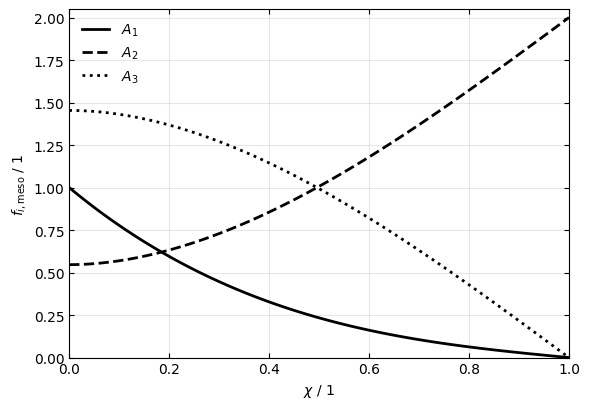

In [6]:
fig, ax = plt.subplots(figsize=(6.0, 4.2))
ax.plot(chi_plot, profiles[0], color="black", linewidth=2.0, linestyle="-", label=r"$A_1$")
ax.plot(chi_plot, profiles[1], color="black", linewidth=2.0, linestyle="--", label=r"$A_2$")
ax.plot(chi_plot, profiles[2], color="black", linewidth=2.0, linestyle=":", label=r"$A_3$")
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 2.05)
ax.set_xlabel(r"$\chi$ / 1")
ax.set_ylabel(r"$f_{i,\mathrm{meso}}$ / 1")
ax.tick_params(axis="both", direction="in", top=True, right=True)
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## Verification

The checks below verify the boundary residuals, non-negative profiles and the stoichiometric invariant $f_2+f_3=2$, which follows from identical diffusion coefficients and the selected boundary conditions for $A_2$ and $A_3$.


In [7]:
bc_residual = boundary_residuals(solution.y[:, 0], solution.y[:, -1], params)
invariant = profiles[1] + profiles[2]

print(f"max |BC residual| = {np.max(np.abs(bc_residual)):.3e}")
print(f"min(f_i) = {profiles.min():.3e}")
print(f"max |f2 + f3 - 2| = {np.max(np.abs(invariant - 2.0)):.3e}")

assert np.max(np.abs(bc_residual)) < 1e-6
assert profiles.min() > -1e-8
assert np.max(np.abs(invariant - 2.0)) < 1e-6


max |BC residual| = 2.214e-28
min(f_i) = -3.693e-20
max |f2 + f3 - 2| = 0.000e+00
